
# Utsunomiya LRT Agglomeration Benefits Analysis

## Expected results

This notebook extends the preliminary Utsunomiya LRT / Sasaki-style spatial analysis toward **agglomeration benefits**: the economic-efficiency gains that may occur when population, urban functions, and economic activity concentrate along public transit corridors.

Expected outputs:

1. **Corridor density table** by distance from LRT stations/corridor: 0–500m, 500–800m, 800–1000m, 1000–2000m, and 2000m+.
2. **Station catchment agglomeration table** for each LRT stop, using 800m buffers.
3. **Composite agglomeration index** combining population density, working-age density, bus/service density, road density, and land-price level.
4. **Access-adjusted density benefit proxy** comparing existing transit access versus LRT-improved access.
5. **Optional monetary sensitivity estimate** using editable assumptions for income, employment rate, and density-productivity elasticity.
6. Maps and CSV outputs saved under `outputs_agglomeration/`.

The results should be interpreted as **preliminary spatial evidence**, not as a causal proof. The strongest defensible claim is whether LRT-served areas are already dense, connected, and institutionally/service-rich enough to plausibly support agglomeration benefits, and whether future population projections suggest continued concentration along the corridor.


In [34]:
# Imports and global settings
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

warnings.filterwarnings("ignore", category=UserWarning)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs_agglomeration")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
SHP_DIR = OUTPUT_DIR / "shapefiles"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, SHP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Coordinate systems
CRS_WGS84 = "EPSG:4326"
CRS_JGD2011_GEOG = "EPSG:6668"
CRS_ANALYSIS = "EPSG:6678"  # JGD2011 / Japan Plane Rectangular CS IX, meters

# Modeling assumptions
OPEN_YEAR = 2023
ANALYSIS_YEARS = 40
DISCOUNT_RATE = 0.04
AVG_HH_SIZE = 2.2
HOUSEHOLD_INCOME_YEN = 4_500_000  # Replace with municipal-taxation income if available.
LATEST_LRT_COST_MILLION_YEN = 68_400.0  # 684 oku yen, latest public project-cost assumption used in prior step.
FEEDER_EXTRA_COST_MILLION_YEN = 63_617.6 - 59_615.6  # same incremental feeder cost from paper, as default
AVG_WORKER_INCOME_YEN = 4_500_000
EMPLOYMENT_RATE = 0.65
DENSITY_PRODUCTIVITY_ELASTICITY = 0.03
ACCESS_DECAY_PER_MIN = 0.05
WALK_SPEED_M_PER_MIN = 80
STATION_BUFFER_M = 800

# Travel assumptions used to approximate Sasaki/Sato variables when timetable data are not available.
WALK_SPEED_M_PER_MIN = 80.0
ROAD_DISTANCE_FACTOR = 1.1666
LRT_END_TO_END_MIN = 44.0       # edit if you use official timetable by stop
PT_FALLBACK_SPEED_M_PER_MIN = 500.0
DEFAULT_GROCERY_WALK_MIN = 10.0
DEFAULT_FLOOD_DEPTH_M = 0.0

print("Output folders:")
print(" -", FIG_DIR)
print(" -", TABLE_DIR)
print(" -", SHP_DIR)

Output folders:
 - outputs_agglomeration/figures
 - outputs_agglomeration/tables
 - outputs_agglomeration/shapefiles


In [15]:
print("Current working directory:")
print(Path.cwd())

print("\nDoes data exist?", Path("data").exists())
print("Does dat exist?", Path("dat").exists())

print("\nFiles/folders directly inside data:")
for p in Path("data").iterdir():
    print(p)

print("\nAll shapefiles under data:")
for p in Path("data").rglob("*.shp"):
    print(p)

Current working directory:
/home/miwatanabe/private/asgn3

Does data exist? True
Does dat exist? False

Files/folders directly inside data:
data/outputs_agglomeration

All shapefiles under data:


In [21]:
import os
from pathlib import Path
# Check current working directory
print("Before:", Path.cwd())

# Change to your project folder
os.chdir("/home/miwatanabe/private/UtsunomiyaLRT")

# Check again
print("After:", Path.cwd())

Before: /home/miwatanabe/private/asgn3
After: /home/miwatanabe/private/UtsunomiyaLRT



## 1. Data discovery and loading

This follows the same approach as the attached preliminary notebook: discover expected shapefiles, load them with encoding fallbacks, and convert all spatial layers to **EPSG:6678** so distance, area, buffer, and density calculations are in meters.


In [23]:
# Edit these if your filenames differ.
LAYER_PATTERNS = {
    "adm1": ["gadm41_JPN_1.shp", "*JPN*1*.shp", "*adm*1*.shp"],
    "adm2": ["gadm41_JPN_2.shp", "*JPN*2*.shp", "*adm*2*.shp"],
    "pop_mesh": ["250m_mesh_2024_09.shp", "*250m*mesh*.shp", "*mesh*2024*.shp", "*population*mesh*.shp"],
    "bus_stops": ["P11-22_09.shp", "P11*.shp", "*bus*stop*.shp", "*bus*.shp"],
    "rail_lines": ["RailroadSection2.shp", "*RailroadSection*.shp", "*rail*line*.shp"],
    "rail_stations": ["Station2.shp", "*Station*.shp", "*rail*station*.shp"],
    "land_price": ["L01-26_09.shp", "L01*.shp", "*land*price*.shp", "*地価*.shp"],
    "roads": ["N13-24_5439.shp", "N13*.shp", "*road*.shp", "*道路*.shp"],
    "lrt_stops": ["lrt_stops.shp", "*lrt*stop*.shp", "*lightline*stop*.shp", "*ライトライン*停*.shp"],
    "feeder_stops": ["feeder_stops.shp", "*feeder*stop*.shp", "*fbs*stop*.shp"],
    "hospitals": ["utsunomiya_hospitals_clinics.shp", "*hospital*.shp", "*byouin*.shp", "*病院*.shp"],
    "clinics": ["utsunomiya_clinics.shp", "*clinic*.shp", "*sinryojo*.shp", "*診療*.shp"],
    "grocery": ["grocery_stores.shp", "*grocery*.shp", "*supermarket*.shp", "*スーパー*.shp"],
    "flood": ["flood_depth_by_mesh.shp", "*flood*.shp", "*hazard*.shp", "*洪水*.shp"],
}

def find_layer(key, required=False):
    patterns = LAYER_PATTERNS[key]
    matches = []
    for pat in patterns:
        matches.extend(sorted(DATA_DIR.rglob(pat)))
    # Deduplicate while preserving order
    seen = set()
    unique = []
    for m in matches:
        if m.resolve() not in seen:
            seen.add(m.resolve())
            unique.append(m)
    if unique:
        print(f"{key:15s} -> {unique[0]}")
        return unique[0]
    if required:
        raise FileNotFoundError(f"Required layer '{key}' not found under {DATA_DIR}. Patterns: {patterns}")
    print(f"{key:15s} -> not found, skipped")
    return None

layer_paths = {k: find_layer(k, required=k in ["pop_mesh", "lrt_stops"]) for k in LAYER_PATTERNS}

adm1            -> data/gadm41_JPN_1.shp
adm2            -> data/gadm41_JPN_2.shp
pop_mesh        -> data/250m_mesh_2024_09.shp
bus_stops       -> data/P11-22_09.shp
rail_lines      -> data/N05-25_RailroadSection2.shp
rail_stations   -> data/N05-25_Station2.shp
land_price      -> data/L01-26_09.shp
roads           -> data/N13-24_5439.shp
lrt_stops       -> data/lrt_stops.shp
feeder_stops    -> not found, skipped
hospitals       -> data/utsunomiya_hospitals_clinics.shp
clinics         -> data/utsunomiya_clinics.shp
grocery         -> not found, skipped
flood           -> not found, skipped


In [26]:

def read_shp(path, target_crs=CRS_ANALYSIS, encoding_candidates=("utf-8", "cp932", "shift_jis")):
    if path is None:
        return None
    last_err = None
    for enc in encoding_candidates:
        try:
            gdf = gpd.read_file(path, encoding=enc)
            break
        except Exception as e:
            last_err = e
    else:
        raise last_err
    if gdf.crs is None:
        # Most Japanese national land numerical information datasets are distributed in geographic CRS.
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)
    return gdf.to_crs(target_crs)

def first_existing_col(gdf, candidates):
    if gdf is None:
        return None
    lower = {c.lower(): c for c in gdf.columns}
    for c in candidates:
        if c in gdf.columns:
            return c
        if c.lower() in lower:
            return lower[c.lower()]
    return None

def geom_union(gdf):
    if gdf is None or len(gdf) == 0:
        return None
    if hasattr(gdf.geometry, "union_all"):
        return gdf.geometry.union_all()
    return gdf.geometry.unary_union

def standardize_point_layer(gdf):
    if gdf is None or len(gdf) == 0:
        return gdf
    gdf = gdf.copy()
    if not all(gdf.geometry.geom_type.isin(["Point", "MultiPoint"])):
        gdf["geometry"] = gdf.geometry.centroid
    return gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf.crs).to_crs(CRS_ANALYSIS)

adm2 = read_shp(layer_paths["adm2"])
pop = read_shp(layer_paths["pop_mesh"])
bus = standardize_point_layer(read_shp(layer_paths["bus_stops"]))
rail_lines = read_shp(layer_paths["rail_lines"])
rail_stations = standardize_point_layer(read_shp(layer_paths["rail_stations"]))
land = standardize_point_layer(read_shp(layer_paths["land_price"]))
roads = read_shp(layer_paths["roads"])
lrt_stops = standardize_point_layer(read_shp(layer_paths["lrt_stops"]))
hospitals = standardize_point_layer(read_shp(layer_paths["hospitals"]))
clinics = standardize_point_layer(read_shp(layer_paths["clinics"]))
grocery = standardize_point_layer(read_shp(layer_paths["grocery"]))

required = {"pop_mesh": pop, "lrt_stops": lrt_stops}
missing_required = [k for k, v in required.items() if v is None or len(v) == 0]
if missing_required:
    raise FileNotFoundError(f"Missing required layers: {missing_required}. Put data under data/ or dat/ and rerun.")

for name, gdf in {
    "adm2": adm2, "pop": pop, "bus": bus, "rail_lines": rail_lines, "rail_stations": rail_stations,
    "land": land, "roads": roads, "lrt_stops": lrt_stops, "hospitals": hospitals, "clinics": clinics, "grocery": grocery
}.items():
    if gdf is not None:
        print(f"{name:14s}: {len(gdf):,} features, geometry={gdf.geometry.geom_type.mode().iat[0]}")


adm2          : 1,811 features, geometry=Polygon
pop           : 34,921 features, geometry=Polygon
bus           : 3,778 features, geometry=Point
rail_lines    : 2,653 features, geometry=LineString
rail_stations : 23,864 features, geometry=Point
land          : 458 features, geometry=Point
roads         : 1,267,863 features, geometry=LineString
lrt_stops     : 34 features, geometry=Point
hospitals     : 470 features, geometry=Point
clinics       : 437 features, geometry=Point



## 2. Study area and clipping

I define the study area as Utsunomiya City plus Haga Town when administrative boundaries are available, because the LRT corridor connects Utsunomiya with Haga. If boundaries are unavailable, the fallback is a 3km buffer around LRT stops.


In [38]:

def contains_any(series, keywords):
    s = series.astype(str).fillna("")
    mask = pd.Series(False, index=series.index)
    for kw in keywords:
        mask = mask | s.str.contains(kw, case=False, regex=False, na=False)
    return mask

def select_study_area(adm2, lrt_stops, buffer_m=3000):
    if adm2 is not None and len(adm2):
        name_cols = [c for c in ["NAME_2", "NL_NAME_2", "VARNAME_2", "NAME_1", "NL_NAME_1"] if c in adm2.columns]
        mask = pd.Series(False, index=adm2.index)
        for c in name_cols:
            mask = mask | contains_any(adm2[c], ["Utsunomiya", "宇都宮", "Haga", "芳賀"])
        if mask.any():
            return adm2.loc[mask].copy()
    # fallback: LRT corridor study area
    return gpd.GeoDataFrame(geometry=[geom_union(lrt_stops).buffer(buffer_m)], crs=CRS_ANALYSIS)

def clip_to_study(gdf, study_area):
    if gdf is None or len(gdf) == 0:
        return gdf
    return gpd.clip(gdf, study_area).reset_index(drop=True)

study_area = select_study_area(adm2, lrt_stops)
study_union = geom_union(study_area)

pop = clip_to_study(pop, study_area)
bus = clip_to_study(bus, study_area)
rail_lines = clip_to_study(rail_lines, study_area)
rail_stations = clip_to_study(rail_stations, study_area)
land = clip_to_study(land, study_area)
roads = clip_to_study(roads, study_area)
lrt_stops = clip_to_study(lrt_stops, study_area)
hospitals = clip_to_study(hospitals, study_area)
clinics = clip_to_study(clinics, study_area)
grocery = clip_to_study(grocery, study_area)

print("Clipped study layers:")
for name, gdf in {"pop": pop, "bus": bus, "rail_stations": rail_stations, "land": land, "roads": roads, "lrt_stops": lrt_stops, "hospitals": hospitals, "clinics": clinics, "grocery": grocery}.items():
    if gdf is not None:
        print(f"{name:14s}: {len(gdf):,}")


Clipped study layers:
pop           : 5,061
bus           : 887
rail_stations : 34
land          : 120
roads         : 74,629
lrt_stops     : 34
hospitals     : 470
clinics       : 437



## 3. Core variables for agglomeration analysis

The dependent idea is not simply “near LRT = good.” The measurable agglomeration logic is:

**LRT proximity → higher transit accessibility → stronger concentration of residents, workers, services, and land value → potential economic efficiency gains.**

So the notebook creates these variables:

- `dist_lrt_m`: distance from mesh centroid to the nearest LRT station.
- `lrt_zone`: distance band from the LRT.
- `pop_density_pkm2`: population per square km.
- `work_age_density_pkm2`: working-age population per square km.
- `existing_transit_min`: walking minutes to nearest existing bus/rail stop.
- `lrt_transit_min`: walking minutes to nearest bus/rail/LRT stop.
- `ln_access_density_gain`: log gain in access-adjusted density after adding LRT.


In [27]:

# Detect useful columns from the README-described data structure.
POP_TOTAL_COL = first_existing_col(pop, ["PT00_2025", "PTN_2025", "PTN_2020", "PT00_2020", "population", "pop"])
POP_CHILD_COL = first_existing_col(pop, ["PTA_2025", "PTA_2020", "child_pop"])
POP_WORK_COL = first_existing_col(pop, ["PTB_2025", "PTB_2020", "working_age", "work_pop"])
POP_ELDER_COL = first_existing_col(pop, ["PTC_2025", "PTC_2020", "elderly", "pop65"])
LRT_NAME_COL = first_existing_col(lrt_stops, ["stop_name", "name", "station", "N05_011"])
BUS_NAME_COL = first_existing_col(bus, ["P11_001", "bus_stop", "name"]) if bus is not None else None
LAND_PRICE_COL = first_existing_col(land, ["L01_008", "price", "land_price"])
LAND_YOY_COL = first_existing_col(land, ["L01_009", "yoy", "change_rate"])

print("Detected columns:")
for label, col in {
    "population total": POP_TOTAL_COL,
    "children 0-14": POP_CHILD_COL,
    "working age 15-64": POP_WORK_COL,
    "elderly 65+": POP_ELDER_COL,
    "LRT stop name": LRT_NAME_COL,
    "bus stop name": BUS_NAME_COL,
    "land price": LAND_PRICE_COL,
    "land YoY": LAND_YOY_COL,
}.items():
    print(f"{label:22s}: {col}")

if POP_TOTAL_COL is None:
    raise ValueError("Could not find a population column such as PT00_2025 or PTN_2025.")
if LRT_NAME_COL is None:
    lrt_stops = lrt_stops.copy()
    lrt_stops["lrt_stop"] = [f"LRT_{i:02d}" for i in range(len(lrt_stops))]
    LRT_NAME_COL = "lrt_stop"


Detected columns:
population total      : PT00_2025
children 0-14         : PTA_2025
working age 15-64     : PTB_2025
elderly 65+           : PTC_2025
LRT stop name         : stop_name
bus stop name         : P11_001
land price            : L01_008
land YoY              : L01_009


In [30]:

# Build population-zone layer from native 250m mesh polygons.
zones = pop.copy()
zones["zone_id"] = zones.index.astype(str)
zones["area_km2"] = zones.geometry.area / 1_000_000

for c in [POP_TOTAL_COL, POP_CHILD_COL, POP_WORK_COL, POP_ELDER_COL]:
    if c and c in zones.columns:
        zones[c] = pd.to_numeric(zones[c], errors="coerce").fillna(0)

zones["pop_total"] = zones[POP_TOTAL_COL]
zones["pop_child"] = zones[POP_CHILD_COL] if POP_CHILD_COL else np.nan
zones["pop_work"] = zones[POP_WORK_COL] if POP_WORK_COL else zones["pop_total"] * 0.60
zones["pop65"] = zones[POP_ELDER_COL] if POP_ELDER_COL else np.nan
zones["pop_density_pkm2"] = zones["pop_total"] / zones["area_km2"].replace(0, np.nan)
zones["work_age_density_pkm2"] = zones["pop_work"] / zones["area_km2"].replace(0, np.nan)

centroids = gpd.GeoDataFrame(zones[["zone_id"]].copy(), geometry=zones.geometry.centroid, crs=zones.crs)
lrt_union = geom_union(lrt_stops)
zones["dist_lrt_m"] = centroids.geometry.distance(lrt_union)
zones["lrt_zone"] = pd.cut(
    zones["dist_lrt_m"],
    bins=[0, 500, 800, 1000, 2000, np.inf],
    labels=["0-500m", "500-800m", "800-1000m", "1000-2000m", "2000m+"],
    include_lowest=True
)

# Existing transit = bus + existing rail stations. LRT scenario adds LRT stations.
existing_parts = []
if bus is not None and len(bus):
    existing_parts.append(bus[["geometry"]])
if rail_stations is not None and len(rail_stations):
    existing_parts.append(rail_stations[["geometry"]])
existing_transit = gpd.GeoDataFrame(pd.concat(existing_parts, ignore_index=True), geometry="geometry", crs=CRS_ANALYSIS) if existing_parts else None
existing_union = geom_union(existing_transit) if existing_transit is not None else None

if existing_union is not None:
    zones["dist_existing_transit_m"] = centroids.geometry.distance(existing_union)
else:
    zones["dist_existing_transit_m"] = np.nan
zones["existing_transit_min"] = zones["dist_existing_transit_m"] / WALK_SPEED_M_PER_MIN
zones["lrt_access_min"] = zones["dist_lrt_m"] / WALK_SPEED_M_PER_MIN
zones["lrt_transit_min"] = np.fmin(zones["existing_transit_min"], zones["lrt_access_min"])

# Access-adjusted density proxy. This is a preliminary indicator, not a formal causal estimate.
zones["access_density_no"] = zones["pop_density_pkm2"] * np.exp(-ACCESS_DECAY_PER_MIN * zones["existing_transit_min"].fillna(zones["lrt_access_min"]))
zones["access_density_lrt"] = zones["pop_density_pkm2"] * np.exp(-ACCESS_DECAY_PER_MIN * zones["lrt_transit_min"])
zones["ln_access_density_gain"] = np.log((zones["access_density_lrt"] + 1e-9) / (zones["access_density_no"] + 1e-9))
zones["access_time_gain_min"] = zones["existing_transit_min"] - zones["lrt_transit_min"]

zones[["zone_id", "pop_total", "pop_density_pkm2", "dist_lrt_m", "lrt_zone", "existing_transit_min", "lrt_transit_min", "ln_access_density_gain"]].head()


,zone_id,pop_total,pop_density_pkm2,dist_lrt_m,lrt_zone,existing_transit_min,lrt_transit_min,ln_access_density_gain
0,0,8.4443,129.973586,44432.353657,2000m+,4.718848,4.718848,0.0
1,1,0.0000,0.000000,44299.636733,2000m+,8.188355,8.188355,0.0
2,2,10.5348,162.144368,43470.853074,2000m+,17.513078,17.513078,0.0
3,3,26.2359,403.815425,43260.563977,2000m+,19.618314,19.618314,0.0
4,4,112.8844,1737.529672,43050.488972,2000m+,21.903191,21.903191,0.0



## 4. Corridor-level density analysis

This table tests the first descriptive question: **are people and potential workers already more concentrated near the LRT corridor?**

For agglomeration-benefit logic, higher population density and working-age density near stations means that the LRT is not only a mobility project; it may also support compact urban concentration.


In [31]:

corridor_density = (
    zones.groupby("lrt_zone", observed=True)
    .agg(
        n_mesh=("zone_id", "count"),
        area_km2=("area_km2", "sum"),
        pop_total=("pop_total", "sum"),
        pop_work=("pop_work", "sum"),
        pop65=("pop65", "sum"),
        mean_pop_density_pkm2=("pop_density_pkm2", "mean"),
        mean_work_age_density_pkm2=("work_age_density_pkm2", "mean"),
        mean_existing_transit_min=("existing_transit_min", "mean"),
        mean_lrt_transit_min=("lrt_transit_min", "mean"),
        mean_access_time_gain_min=("access_time_gain_min", "mean"),
        mean_ln_access_density_gain=("ln_access_density_gain", "mean"),
    )
    .reset_index()
)
corridor_density["pop_density_total_pkm2"] = corridor_density["pop_total"] / corridor_density["area_km2"]
corridor_density["work_density_total_pkm2"] = corridor_density["pop_work"] / corridor_density["area_km2"]
corridor_density.to_csv(TABLE_DIR / "corridor_density_by_lrt_distance.csv", index=False, encoding="utf-8-sig")
corridor_density


,lrt_zone,n_mesh,area_km2,pop_total,pop_work,pop65,mean_pop_density_pkm2,mean_work_age_density_pkm2,mean_existing_transit_min,mean_lrt_transit_min,mean_access_time_gain_min,mean_ln_access_density_gain,pop_density_total_pkm2,work_density_total_pkm2
0,0-500m,123,7.954813,2.811938e+04,1.859760e+04,5811.3875,3534.873533,2337.895929,2.364027,2.328887,0.035140,0.001618,3534.889255,2337.905282
1,500-800m,105,6.790817,2.005283e+04,1.294325e+04,4598.6660,2952.970000,1906.020853,4.030415,3.995836,0.034579,0.001212,2952.933147,1905.993003
2,800-1000m,80,5.173879,1.560334e+04,1.006691e+04,3855.2303,3015.759066,1945.703320,4.084236,4.042412,0.041825,0.001402,3015.792171,1945.718405
3,1000-2000m,398,25.740717,6.466995e+04,4.097770e+04,16682.8199,2512.285916,1591.886482,5.262427,5.221494,0.040933,0.001540,2512.360202,1591.941014
4,2000m+,34215,2211.461183,1.738287e+06,1.004070e+06,551517.9036,785.206281,453.531674,15.384114,15.381670,0.002444,0.000104,786.035722,454.029919


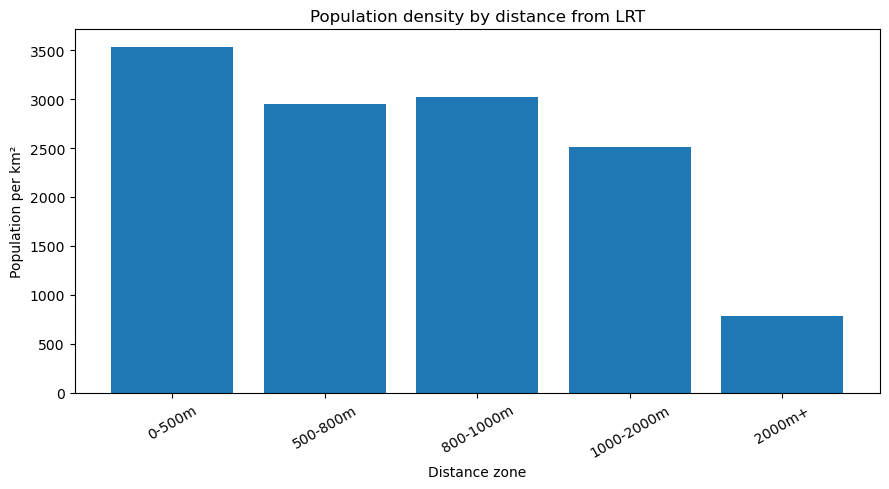

In [32]:

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = corridor_density.dropna(subset=["lrt_zone"]).copy()
ax.bar(plot_df["lrt_zone"].astype(str), plot_df["pop_density_total_pkm2"])
ax.set_title("Population density by distance from LRT")
ax.set_xlabel("Distance zone")
ax.set_ylabel("Population per km²")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "bar_population_density_by_lrt_zone.png", dpi=300, bbox_inches="tight")
plt.show()



## 5. Station catchment agglomeration indicators

This section uses **800m LRT station buffers**. I use area-weighted population overlays because 250m mesh polygons can cross buffer boundaries. Point counts and road lengths are calculated inside each station catchment.


In [35]:

# Build station buffers
station_buffers = lrt_stops[[LRT_NAME_COL, "geometry"]].copy().rename(columns={LRT_NAME_COL: "lrt_stop"})
station_buffers["geometry"] = station_buffers.geometry.buffer(STATION_BUFFER_M)
station_buffers["buf_area_km2"] = station_buffers.geometry.area / 1_000_000
station_buffers = gpd.GeoDataFrame(station_buffers, geometry="geometry", crs=CRS_ANALYSIS)

corridor_buffer = gpd.GeoDataFrame({"name": [f"LRT corridor {STATION_BUFFER_M}m"]}, geometry=[geom_union(station_buffers)], crs=CRS_ANALYSIS)
corridor_buffer["area_km2"] = corridor_buffer.geometry.area / 1_000_000

# Weighted overlay function for polygon population into buffers.
def weighted_sum_to_buffers(source_polys, buffers, value_cols, buffer_id="lrt_stop"):
    src = source_polys[["zone_id", "geometry"] + [c for c in value_cols if c in source_polys.columns]].copy()
    src["src_area"] = src.geometry.area
    inter = gpd.overlay(src, buffers[[buffer_id, "geometry"]], how="intersection")
    if len(inter) == 0:
        return buffers[[buffer_id]].copy()
    inter["w"] = inter.geometry.area / inter["src_area"].replace(0, np.nan)
    out = buffers[[buffer_id]].copy()
    for c in value_cols:
        if c in inter.columns:
            inter[f"weighted_{c}"] = pd.to_numeric(inter[c], errors="coerce").fillna(0) * inter["w"]
            s = inter.groupby(buffer_id)[f"weighted_{c}"].sum().rename(c).reset_index()
            out = out.merge(s, on=buffer_id, how="left")
    return out.fillna(0)

pop_values = ["pop_total", "pop_child", "pop_work", "pop65"]
station_pop = weighted_sum_to_buffers(zones, station_buffers, pop_values, buffer_id="lrt_stop")
station_summary = station_buffers[["lrt_stop", "buf_area_km2", "geometry"]].merge(station_pop, on="lrt_stop", how="left").fillna(0)

# Count points inside station buffers.
def count_points(points, buffers, label, unique_col=None, buffer_id="lrt_stop"):
    out = buffers[[buffer_id]].copy()
    if points is None or len(points) == 0:
        out[label] = 0
        return out
    cols = ["geometry"] + ([unique_col] if unique_col and unique_col in points.columns else [])
    j = gpd.sjoin(points[cols], buffers[[buffer_id, "geometry"]], predicate="within", how="inner")
    if len(j) == 0:
        out[label] = 0
        return out
    if unique_col and unique_col in j.columns:
        s = j.groupby(buffer_id)[unique_col].nunique().rename(label).reset_index()
    else:
        s = j.groupby(buffer_id).size().rename(label).reset_index()
    return out.merge(s, on=buffer_id, how="left").fillna({label: 0})

for pts, label, ucol in [
    (bus, "bus_stops_800m", BUS_NAME_COL),
    (rail_stations, "rail_stations_800m", None),
    (hospitals, "hospitals_800m", None),
    (clinics, "clinics_800m", None),
    (grocery, "grocery_800m", None),
]:
    station_summary = station_summary.merge(count_points(pts, station_buffers, label, unique_col=ucol), on="lrt_stop", how="left")

# Road length inside station buffers.
if roads is not None and len(roads):
    road_inter = gpd.overlay(roads[["geometry"]], station_buffers[["lrt_stop", "geometry"]], how="intersection")
    if len(road_inter):
        road_inter["road_km"] = road_inter.geometry.length / 1000
        road_sum = road_inter.groupby("lrt_stop")["road_km"].sum().reset_index()
        station_summary = station_summary.merge(road_sum, on="lrt_stop", how="left")
station_summary["road_km"] = station_summary.get("road_km", 0).fillna(0)

# Land price inside station buffers.
if land is not None and len(land) and LAND_PRICE_COL:
    land2 = land.copy()
    land2[LAND_PRICE_COL] = pd.to_numeric(land2[LAND_PRICE_COL], errors="coerce")
    if LAND_YOY_COL:
        land2[LAND_YOY_COL] = pd.to_numeric(land2[LAND_YOY_COL], errors="coerce")
    j = gpd.sjoin(land2[[LAND_PRICE_COL, LAND_YOY_COL, "geometry"] if LAND_YOY_COL else [LAND_PRICE_COL, "geometry"]], station_buffers[["lrt_stop", "geometry"]], predicate="within", how="inner")
    if len(j):
        agg_dict = {LAND_PRICE_COL: ["count", "mean", "median"]}
        if LAND_YOY_COL:
            agg_dict[LAND_YOY_COL] = "mean"
        land_stats = j.groupby("lrt_stop").agg(agg_dict)
        land_stats.columns = ["land_n", "mean_land_price_yen_m2", "median_land_price_yen_m2"] + (["mean_land_yoy_pct"] if LAND_YOY_COL else [])
        land_stats = land_stats.reset_index()
        station_summary = station_summary.merge(land_stats, on="lrt_stop", how="left")

for c in ["land_n", "mean_land_price_yen_m2", "median_land_price_yen_m2", "mean_land_yoy_pct"]:
    if c not in station_summary.columns:
        station_summary[c] = np.nan

# Densities
station_summary["pop_density_pkm2"] = station_summary["pop_total"] / station_summary["buf_area_km2"]
station_summary["work_age_density_pkm2"] = station_summary["pop_work"] / station_summary["buf_area_km2"]
station_summary["bus_stops_per_km2"] = station_summary["bus_stops_800m"] / station_summary["buf_area_km2"]
station_summary["services_800m"] = station_summary[["hospitals_800m", "clinics_800m", "grocery_800m"]].fillna(0).sum(axis=1)
station_summary["services_per_km2"] = station_summary["services_800m"] / station_summary["buf_area_km2"]
station_summary["road_density_km_per_km2"] = station_summary["road_km"] / station_summary["buf_area_km2"]

station_summary.sort_values("pop_density_pkm2", ascending=False).head(10)


,lrt_stop,buf_area_km2,geometry,pop_total,pop_child,pop_work,pop65,bus_stops_800m,rail_stations_800m,hospitals_800m,...,land_n,mean_land_price_yen_m2,median_land_price_yen_m2,mean_land_yoy_pct,pop_density_pkm2,work_age_density_pkm2,bus_stops_per_km2,services_800m,services_per_km2,road_density_km_per_km2
1157,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1204,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1191,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1192,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1193,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1194,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1195,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1196,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1197,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873
1198,峰,2.007391,"POLYGON ((-81306.075 -381689.816, -81309.927 -...",26397.358688,3114.480666,17143.248899,6139.629608,18.0,6,34.0,...,6.0,100366.666667,104000.0,2.866667,13150.082989,8540.064496,8.966863,66.0,32.878497,54.005873


In [36]:

# Composite agglomeration index. Higher value = stronger concentration of population, workers, services, roads, and land-market activity.
def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() <= 1 or s.std(skipna=True) == 0:
        return pd.Series(0, index=s.index, dtype=float)
    return (s - s.mean(skipna=True)) / s.std(skipna=True)

index_cols = [
    "pop_density_pkm2",
    "work_age_density_pkm2",
    "bus_stops_per_km2",
    "services_per_km2",
    "road_density_km_per_km2",
    "mean_land_price_yen_m2",
]
for c in index_cols:
    station_summary[f"z_{c}"] = zscore(station_summary[c]).fillna(0)
station_summary["agglomeration_index"] = station_summary[[f"z_{c}" for c in index_cols]].mean(axis=1)

station_table = station_summary.drop(columns="geometry").sort_values("agglomeration_index", ascending=False)
station_table.to_csv(TABLE_DIR / "station_agglomeration_index_800m.csv", index=False, encoding="utf-8-sig")
station_table.head(15)


,lrt_stop,buf_area_km2,pop_total,pop_child,pop_work,pop65,bus_stops_800m,rail_stations_800m,hospitals_800m,clinics_800m,...,services_800m,services_per_km2,road_density_km_per_km2,z_pop_density_pkm2,z_work_age_density_pkm2,z_bus_stops_per_km2,z_services_per_km2,z_road_density_km_per_km2,z_mean_land_price_yen_m2,agglomeration_index
962,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
981,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
994,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
993,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
992,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
991,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
990,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
989,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
988,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347
987,東宿郷,2.007391,25048.535801,2974.990012,17286.305713,4787.240118,29.0,12,70.0,66.0,...,136.0,67.74963,54.933805,1.456906,1.545676,2.106222,2.742381,1.102158,2.292742,1.874347


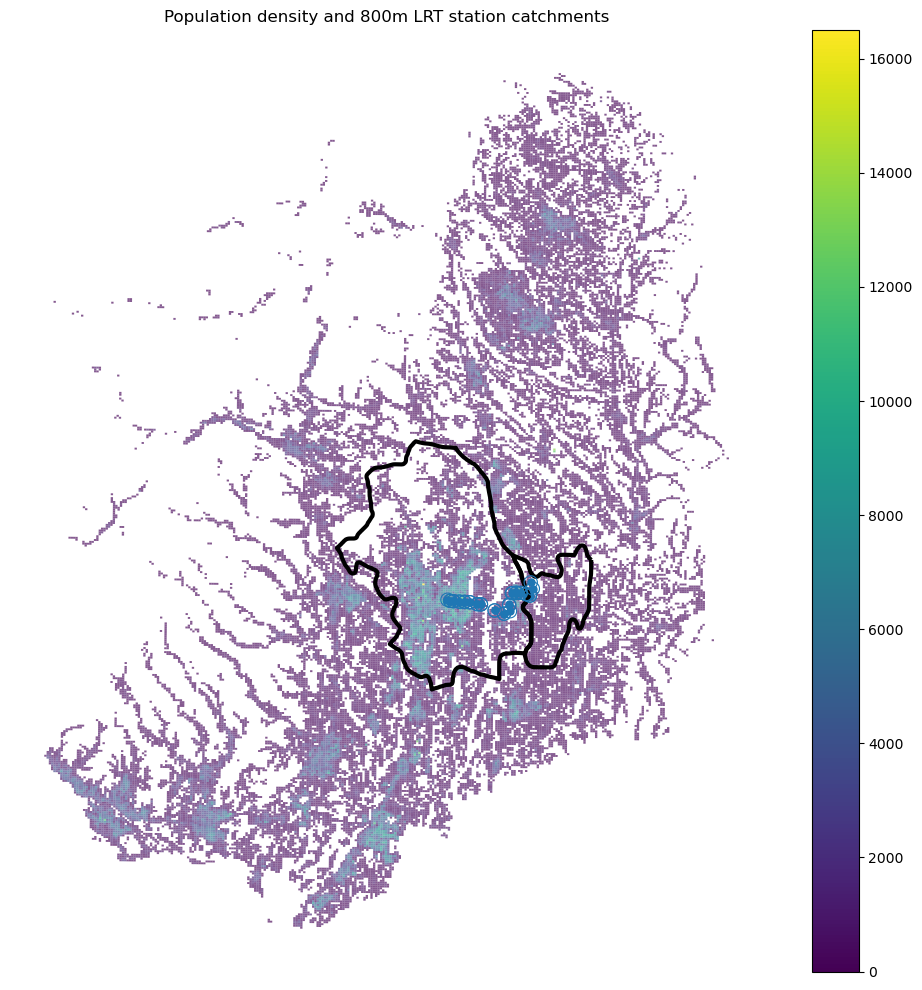

In [41]:

fig, ax = plt.subplots(figsize=(10, 10))
study_area.boundary.plot(ax=ax, linewidth=3, color = 'black')
zones.plot(ax=ax, column="pop_density_pkm2", legend=True, edgecolor="none", alpha=0.65)
station_buffers.boundary.plot(ax=ax, linewidth=0.8)
lrt_stops.plot(ax=ax, markersize=25)
ax.set_title("Population density and 800m LRT station catchments")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "map_population_density_lrt_800m.png", dpi=300, bbox_inches="tight")
plt.show()


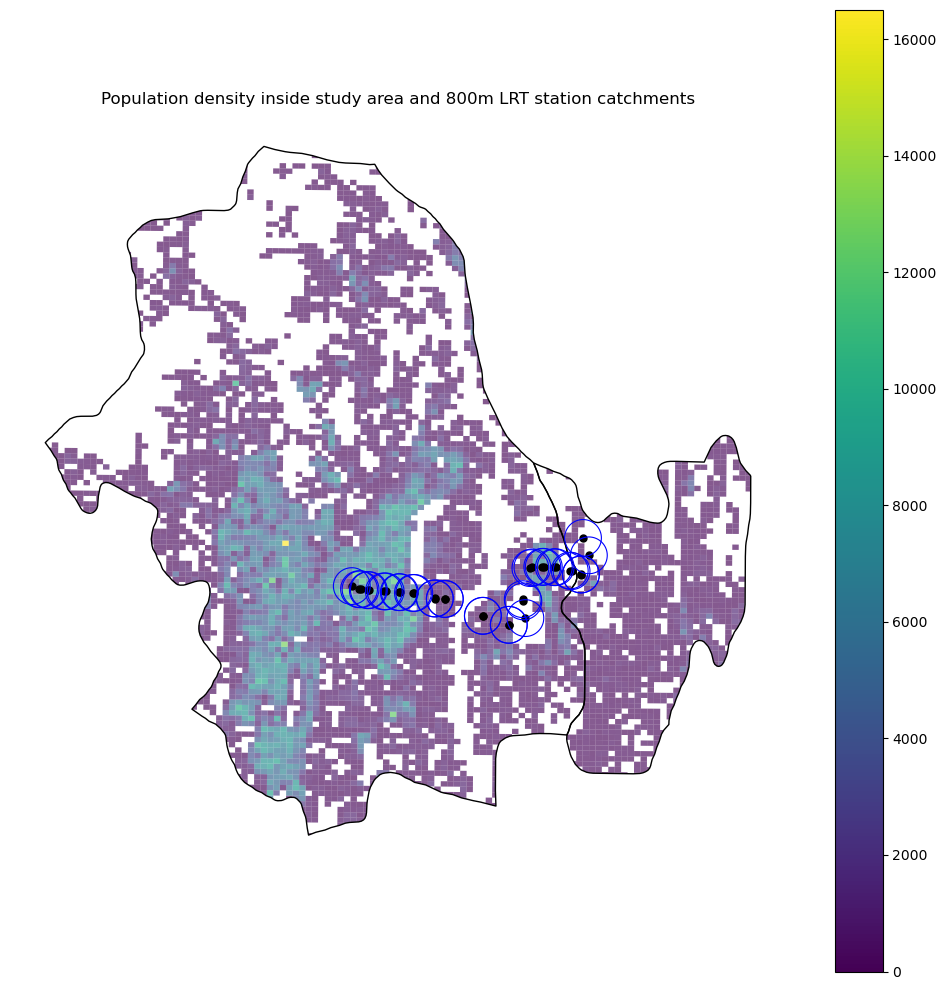

In [44]:
# Make sure both layers use the same CRS
study_area = study_area.to_crs(zones.crs)

# Clip population density zones to the study area
zones_in_study = gpd.clip(zones, study_area)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot only clipped population density layer
zones_in_study.plot(
    ax=ax,
    column="pop_density_pkm2",
    legend=True,
    edgecolor="none",
    alpha=0.65,
    cmap="viridis"
)

# Study area boundary
study_area.boundary.plot(
    ax=ax,
    linewidth=1,
    color="black"
)

# Optional: only show station buffers inside study area too
station_buffers_in_study = gpd.clip(station_buffers, study_area)
station_buffers_in_study.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="blue"
)

# Optional: only show LRT stops inside study area
lrt_stops_in_study = gpd.sjoin(
    lrt_stops,
    study_area[["geometry"]],
    how="inner",
    predicate="within"
)

lrt_stops_in_study.plot(
    ax=ax,
    markersize=25,
    color="black"
)

ax.set_title("Population density inside study area and 800m LRT station catchments")
ax.set_axis_off()

plt.tight_layout()
plt.savefig(FIG_DIR / "map_population_density_lrt_800m_study_area.png", dpi=300, bbox_inches="tight")
plt.show()

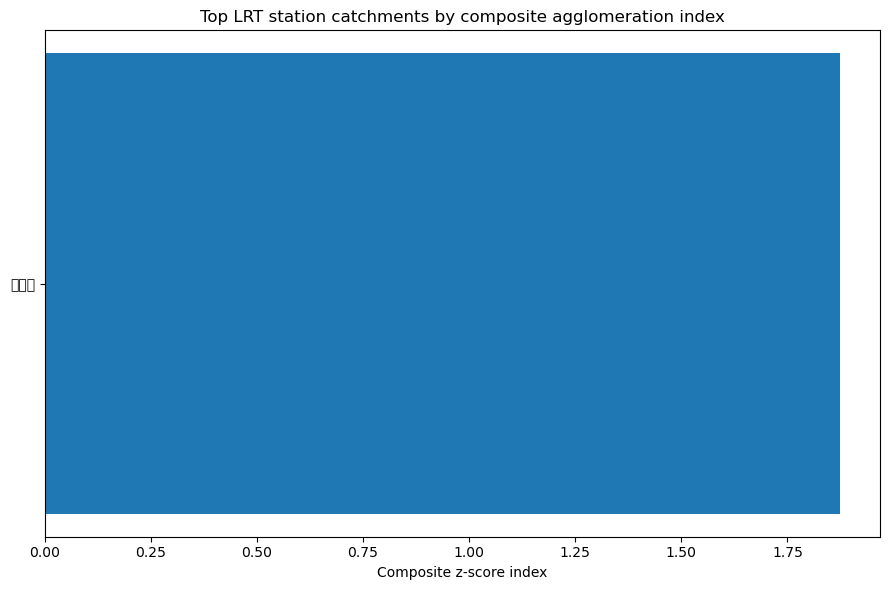

In [45]:

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = station_table.head(12).sort_values("agglomeration_index")
ax.barh(plot_df["lrt_stop"].astype(str), plot_df["agglomeration_index"])
ax.set_title("Top LRT station catchments by composite agglomeration index")
ax.set_xlabel("Composite z-score index")
plt.tight_layout()
plt.savefig(FIG_DIR / "bar_top_station_agglomeration_index.png", dpi=300, bbox_inches="tight")
plt.show()



## 6. Future population concentration near LRT

The README says the 250m mesh data include future population estimates from 2025 to 2070. This section checks whether future projected population is stable or declining differently inside the LRT catchment compared with outside areas.

This matters because agglomeration benefit is more plausible when a transit corridor can maintain or attract population concentration over time.


In [46]:

# Detect total population projection columns, such as PT00_2025, PT00_2030, ... or PTN_2025.
projection_cols = []
for c in zones.columns:
    if c.startswith("PT00_") or c.startswith("PTN_"):
        suffix = c.split("_")[-1]
        if suffix.isdigit() and 2020 <= int(suffix) <= 2070:
            projection_cols.append(c)
projection_cols = sorted(set(projection_cols), key=lambda x: int(x.split("_")[-1]))
print("Detected projection columns:", projection_cols)

if projection_cols:
    trend_rows = []
    for c in projection_cols:
        year = int(c.split("_")[-1])
        temp = zones.copy()
        temp[c] = pd.to_numeric(temp[c], errors="coerce").fillna(0)
        temp["in_lrt_800m"] = temp["dist_lrt_m"] <= 800
        row = {"year": year}
        for flag, label in [(True, "inside_800m"), (False, "outside_800m")]:
            sub = temp[temp["in_lrt_800m"] == flag]
            row[f"pop_{label}"] = sub[c].sum()
            row[f"density_{label}_pkm2"] = sub[c].sum() / (sub.geometry.area.sum() / 1_000_000)
        trend_rows.append(row)
    future_trend = pd.DataFrame(trend_rows)
    base = future_trend.iloc[0]
    for col in [c for c in future_trend.columns if c.startswith("pop_") or c.startswith("density_")]:
        future_trend[f"{col}_idx"] = future_trend[col] / base[col] * 100 if base[col] else np.nan
    future_trend.to_csv(TABLE_DIR / "future_population_inside_outside_lrt_800m.csv", index=False, encoding="utf-8-sig")
    display(future_trend)
else:
    print("No future total population columns detected. Skip this section.")


Detected projection columns: ['PTN_2020', 'PT00_2025', 'PTN_2025', 'PT00_2030', 'PTN_2030', 'PTN_2035', 'PT00_2035', 'PT00_2040', 'PTN_2040', 'PT00_2045', 'PTN_2045', 'PT00_2050', 'PTN_2050', 'PT00_2055', 'PTN_2055', 'PT00_2060', 'PTN_2060', 'PTN_2065', 'PT00_2065', 'PT00_2070', 'PTN_2070']


,year,pop_inside_800m,density_inside_800m_pkm2,pop_outside_800m,density_outside_800m_pkm2,pop_inside_800m_idx,density_inside_800m_pkm2_idx,pop_outside_800m_idx,density_outside_800m_pkm2_idx
0,2020,48971.3659,3321.076557,1.884175e+06,840.258198,100.000000,100.000000,100.000000,100.000000
1,2025,48172.2113,3266.880527,1.818561e+06,810.997337,98.368119,98.368119,96.517635,96.517635
2,2025,48171.2848,3266.817695,1.818562e+06,810.997754,98.366227,98.366227,96.517684,96.517684
3,2030,47900.9698,3248.485823,1.753795e+06,782.114688,97.814241,97.814241,93.080281,93.080281
4,2030,47899.5430,3248.389062,1.753796e+06,782.115325,97.811327,97.811327,93.080356,93.080356
5,2035,47488.9694,3220.545314,1.684854e+06,751.370062,96.972932,96.972932,89.421331,89.421331
6,2035,47491.2815,3220.702113,1.684852e+06,751.369031,96.977653,96.977653,89.421208,89.421208
7,2040,47159.7040,3198.215621,1.611162e+06,718.506818,96.300569,96.300569,85.510242,85.510242
8,2040,47164.9171,3198.569156,1.611157e+06,718.504492,96.311214,96.311214,85.509965,85.509965
9,2045,46777.1899,3172.274776,1.534019e+06,684.104254,95.519472,95.519472,81.415957,81.415957


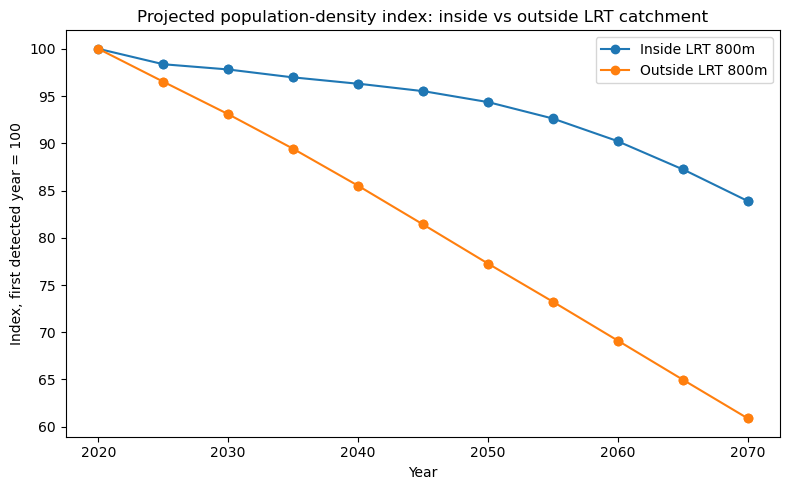

In [47]:

if 'future_trend' in globals() and len(future_trend):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(future_trend["year"], future_trend["density_inside_800m_pkm2_idx"], marker="o", label="Inside LRT 800m")
    ax.plot(future_trend["year"], future_trend["density_outside_800m_pkm2_idx"], marker="o", label="Outside LRT 800m")
    ax.set_title("Projected population-density index: inside vs outside LRT catchment")
    ax.set_xlabel("Year")
    ax.set_ylabel("Index, first detected year = 100")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "line_future_density_inside_outside_lrt_800m.png", dpi=300, bbox_inches="tight")
    plt.show()



## 7. Access-adjusted density benefit proxy

This section translates the spatial idea into a preliminary benefit indicator:

1. Existing condition: each mesh has access to the nearest bus or existing railway station.
2. LRT condition: each mesh has access to the nearest bus, existing railway station, or LRT station.
3. Access-adjusted density improves when the LRT reduces access time to public transit.
4. A sensitivity formula converts that improvement into a rough annual yen value.

Formula used:

\[
Benefit_i = Workers_i \times Income \times Elasticity \times \ln\left(\frac{AccessDensity_{LRT,i}}{AccessDensity_{NoLRT,i}}\right)
\]

This is useful for scenario comparison, but it is not yet a published causal estimate for Utsunomiya.


In [48]:

zones["workers_proxy"] = zones["pop_work"].fillna(0) * EMPLOYMENT_RATE
zones["agglom_benefit_yen"] = (
    zones["workers_proxy"]
    * AVG_WORKER_INCOME_YEN
    * DENSITY_PRODUCTIVITY_ELASTICITY
    * zones["ln_access_density_gain"].clip(lower=0)
)

benefit_by_zone = (
    zones.groupby("lrt_zone", observed=True)
    .agg(
        workers_proxy=("workers_proxy", "sum"),
        mean_ln_access_density_gain=("ln_access_density_gain", "mean"),
        total_agglom_benefit_yen=("agglom_benefit_yen", "sum"),
    )
    .reset_index()
)
benefit_by_zone["total_agglom_benefit_myen"] = benefit_by_zone["total_agglom_benefit_yen"] / 1_000_000
benefit_by_zone.to_csv(TABLE_DIR / "access_adjusted_density_benefit_by_lrt_zone.csv", index=False, encoding="utf-8-sig")
benefit_by_zone


,lrt_zone,workers_proxy,mean_ln_access_density_gain,total_agglom_benefit_yen,total_agglom_benefit_myen
0,0-500m,12088.439220,0.001618,1.851061e+06,1.851061
1,500-800m,8413.112500,0.001212,2.182683e+05,0.218268
2,800-1000m,6543.492670,0.001402,1.069285e+05,0.106929
3,1000-2000m,26635.507535,0.001540,3.966990e+05,0.396699
4,2000m+,652645.201650,0.000104,2.513266e+06,2.513266


In [49]:

total_annual_benefit = zones["agglom_benefit_yen"].sum()
summary = pd.DataFrame({
    "assumption": ["average worker income", "employment rate", "density-productivity elasticity", "access decay per minute", "estimated annual agglomeration benefit"],
    "value": [AVG_WORKER_INCOME_YEN, EMPLOYMENT_RATE, DENSITY_PRODUCTIVITY_ELASTICITY, ACCESS_DECAY_PER_MIN, total_annual_benefit],
    "unit": ["yen/year", "share", "elasticity", "decay", "yen/year"]
})
summary.to_csv(TABLE_DIR / "agglomeration_benefit_sensitivity_summary.csv", index=False, encoding="utf-8-sig")
summary


,assumption,value,unit
0,average worker income,4.500000e+06,yen/year
1,employment rate,6.500000e-01,share
2,density-productivity elasticity,3.000000e-02,elasticity
3,access decay per minute,5.000000e-02,decay
4,estimated annual agglomeration benefit,5.086223e+06,yen/year


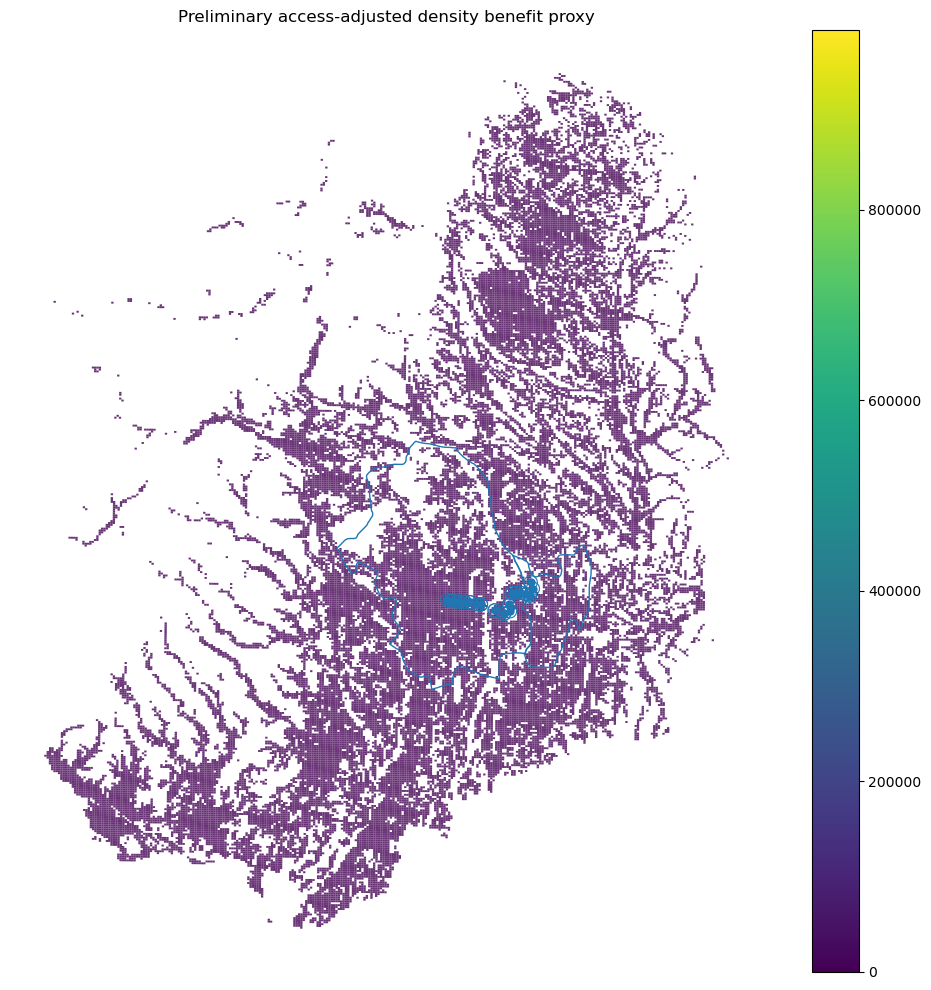

In [50]:

fig, ax = plt.subplots(figsize=(10, 10))
study_area.boundary.plot(ax=ax, linewidth=1)
zones.plot(ax=ax, column="agglom_benefit_yen", legend=True, edgecolor="none", alpha=0.8)
lrt_stops.plot(ax=ax, markersize=25)
station_buffers.boundary.plot(ax=ax, linewidth=0.8)
ax.set_title("Preliminary access-adjusted density benefit proxy")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "map_access_adjusted_density_benefit_proxy.png", dpi=300, bbox_inches="tight")
plt.show()


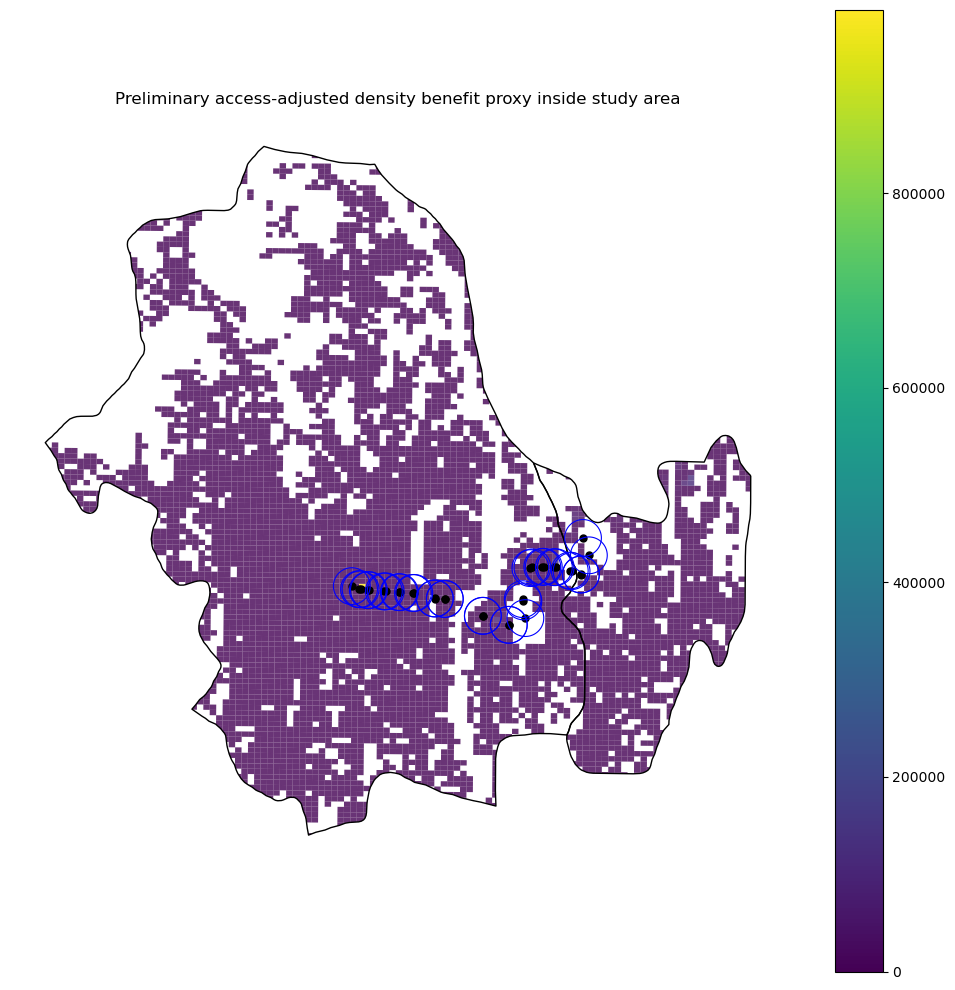

In [52]:
# Make sure CRS matches
study_area = study_area.to_crs(zones.crs)
station_buffers = station_buffers.to_crs(zones.crs)
lrt_stops = lrt_stops.to_crs(zones.crs)

# Clip layers to study area
zones_in_study = gpd.clip(zones, study_area)
station_buffers_in_study = gpd.clip(station_buffers, study_area)

# Keep only LRT stops inside study area
lrt_stops_in_study = gpd.sjoin(
    lrt_stops,
    study_area[["geometry"]],
    how="inner",
    predicate="within"
)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot only benefit proxy inside study area
zones_in_study.plot(
    ax=ax,
    column="agglom_benefit_yen",
    legend=True,
    edgecolor="none",
    alpha=0.8,
    cmap="viridis"
)

# Study area boundary
study_area.boundary.plot(
    ax=ax,
    linewidth=1,
    color="black"
)

# LRT stops inside study area
lrt_stops_in_study.plot(
    ax=ax,
    markersize=25,
    color="black"
)

# Station buffer boundaries clipped to study area
station_buffers_in_study.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="blue"
)

ax.set_title("Preliminary access-adjusted density benefit proxy inside study area")
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    FIG_DIR / "map_access_adjusted_density_benefit_proxy_study_area.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Population density min inside study area: 0.0
Population density max inside study area: 16498.80296897375


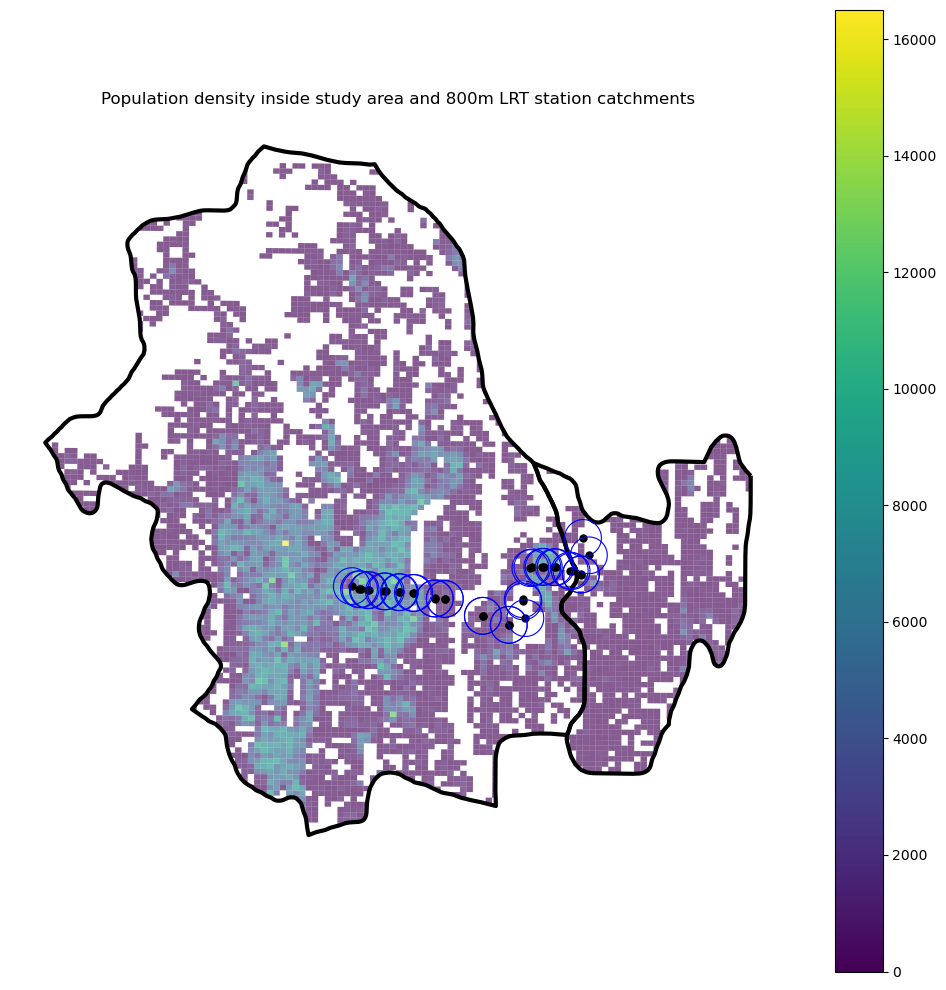

In [54]:
# Make sure CRS matches
study_area = study_area.to_crs(zones.crs)

# Clip zones to study area
zones_in_study = gpd.clip(zones, study_area)

# Get min and max only within study area
vmin = zones_in_study["pop_density_pkm2"].min()
vmax = zones_in_study["pop_density_pkm2"].max()

print("Population density min inside study area:", vmin)
print("Population density max inside study area:", vmax)

fig, ax = plt.subplots(figsize=(10, 10))

zones_in_study.plot(
    ax=ax,
    column="pop_density_pkm2",
    legend=True,
    edgecolor="none",
    alpha=0.65,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

study_area.boundary.plot(
    ax=ax,
    linewidth=3,
    color="black"
)

station_buffers_in_study = gpd.clip(station_buffers.to_crs(zones.crs), study_area)
station_buffers_in_study.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="blue"
)

lrt_stops_in_study = gpd.sjoin(
    lrt_stops.to_crs(zones.crs),
    study_area[["geometry"]],
    how="inner",
    predicate="within"
)

lrt_stops_in_study.plot(
    ax=ax,
    markersize=25,
    color="black"
)

ax.set_title("Population density inside study area and 800m LRT station catchments")
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    FIG_DIR / "map_population_density_lrt_800m_study_area_scaled.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 8. Land-price gradient as an economic-activity proxy

Land price should not be interpreted as a full agglomeration benefit by itself. However, if land-price levels or growth rates are higher near LRT stations, that supports the idea that market activity is more intense near the corridor.

The model below is intentionally simple and preliminary:

\[
\log(price) = \alpha + \beta_1 within800m + \beta_2 distanceToLRT + controls + \epsilon
\]

A positive `within_lrt_800m` coefficient is consistent with corridor concentration, but it is not causal unless the final report adds stronger pre/post and control-area design.


In [55]:

land_model_table = pd.DataFrame()
if land is not None and len(land) and LAND_PRICE_COL:
    land_analysis = land.copy()
    land_analysis[LAND_PRICE_COL] = pd.to_numeric(land_analysis[LAND_PRICE_COL], errors="coerce")
    land_analysis = land_analysis.dropna(subset=[LAND_PRICE_COL]).copy()
    land_analysis = land_analysis[land_analysis[LAND_PRICE_COL] > 0].copy()
    land_analysis["dist_lrt_m"] = land_analysis.geometry.distance(lrt_union)
    land_analysis["within_lrt_800m"] = (land_analysis["dist_lrt_m"] <= 800).astype(int)
    land_analysis["log_price"] = np.log(land_analysis[LAND_PRICE_COL])
    land_analysis["lrt_zone"] = pd.cut(
        land_analysis["dist_lrt_m"],
        bins=[0, 500, 800, 1000, 2000, np.inf],
        labels=["0-500m", "500-800m", "800-1000m", "1000-2000m", "2000m+"],
        include_lowest=True
    )
    land_model_table = (
        land_analysis.groupby("lrt_zone", observed=True)
        .agg(
            n=(LAND_PRICE_COL, "count"),
            mean_price_yen_m2=(LAND_PRICE_COL, "mean"),
            median_price_yen_m2=(LAND_PRICE_COL, "median"),
            mean_distance_lrt_m=("dist_lrt_m", "mean"),
        )
        .reset_index()
    )
    if LAND_YOY_COL and LAND_YOY_COL in land_analysis.columns:
        land_analysis[LAND_YOY_COL] = pd.to_numeric(land_analysis[LAND_YOY_COL], errors="coerce")
        yoy = land_analysis.groupby("lrt_zone", observed=True)[LAND_YOY_COL].mean().rename("mean_yoy_pct").reset_index()
        land_model_table = land_model_table.merge(yoy, on="lrt_zone", how="left")
    land_model_table.to_csv(TABLE_DIR / "land_price_by_lrt_distance_zone.csv", index=False, encoding="utf-8-sig")
    display(land_model_table)

    # Optional OLS if statsmodels is installed.
    try:
        import statsmodels.formula.api as smf
        m = smf.ols("log_price ~ within_lrt_800m + dist_lrt_m", data=land_analysis).fit(cov_type="HC3")
        print(m.summary())
    except Exception as e:
        print("statsmodels OLS skipped:", e)
else:
    print("No land price layer or price column found. Skip land-price gradient section.")


,lrt_zone,n,mean_price_yen_m2,median_price_yen_m2,mean_distance_lrt_m,mean_yoy_pct
0,0-500m,14,166692.857143,111000.0,287.910000,3.178571
1,500-800m,2,149500.000000,149500.0,589.774505,2.750000
2,800-1000m,6,100283.333333,105700.0,892.387754,1.766667
3,1000-2000m,25,115404.000000,106000.0,1508.010537,1.540000
4,2000m+,73,56836.986301,59200.0,5100.569655,0.569863


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     47.61
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.45e-16
Time:                        00:06:26   Log-Likelihood:                -98.815
No. Observations:                 120   AIC:                             203.6
Df Residuals:                     117   BIC:                             212.0
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          11.5903      0.089    1


## 9. Export shapefiles and final interpretation table

The key outputs are:

- `corridor_density_by_lrt_distance.csv`
- `station_agglomeration_index_800m.csv`
- `future_population_inside_outside_lrt_800m.csv`
- `access_adjusted_density_benefit_by_lrt_zone.csv`
- `agglomeration_zones.shp`
- `station_agglomeration_800m.shp`

Use the CSV tables for writing the report, and use the shapefiles for ArcGIS/QGIS maps.


In [56]:

def safe_export_shp(gdf, path):
    if gdf is None or len(gdf) == 0:
        return None
    gdf = gdf.copy()
    # Shapefile column names are limited; keep a compact subset.
    gdf.columns = [str(c)[:10] if c != "geometry" else c for c in gdf.columns]
    gdf.to_file(path, encoding="utf-8")
    print("Wrote", path)
    return path

zone_export_cols = [
    "zone_id", "pop_total", "pop_work", "pop65", "area_km2", "pop_density_pkm2",
    "dist_lrt_m", "lrt_zone", "existing_transit_min", "lrt_transit_min",
    "access_time_gain_min", "ln_access_density_gain", "agglom_benefit_yen", "geometry"
]
zone_export = zones[[c for c in zone_export_cols if c in zones.columns]].copy()
safe_export_shp(zone_export, SHP_DIR / "agglomeration_zones.shp")
safe_export_shp(station_summary, SHP_DIR / "station_agglomeration_800m.shp")

final_interpretation = pd.DataFrame({
    "analysis_piece": [
        "corridor density",
        "station agglomeration index",
        "future population trend",
        "access-adjusted density benefit",
        "land-price gradient",
    ],
    "what_to_report": [
        "Report whether population and working-age density are higher inside 0-800m than outside the LRT corridor.",
        "Report which station catchments combine dense population, services, bus/rail connectivity, roads, and high land-price proxies.",
        "Report whether projected density inside the LRT catchment stays stronger than outside through future years.",
        "Report the annual benefit proxy only as a sensitivity result based on stated assumptions.",
        "Report whether land price levels/growth are higher near LRT, but avoid causal wording unless using stronger pre/post controls.",
    ],
    "caution": [
        "Density near LRT may reflect pre-existing urban form, not only LRT impact.",
        "Composite index depends on chosen weights and available service layers.",
        "Future mesh data are projections, not observed post-LRT population movement.",
        "Income, elasticity, and access-decay parameters must be justified or varied in sensitivity checks.",
        "Land price points are sparse and may need municipality/use controls.",
    ]
})
final_interpretation.to_csv(TABLE_DIR / "final_interpretation_guide.csv", index=False, encoding="utf-8-sig")
final_interpretation


Wrote outputs_agglomeration/shapefiles/agglomeration_zones.shp


ValueError: GeoDataFrame cannot contain duplicated column names.

here I measured agglomeration benefits by checking whether population, working-age residents, services, transit connections, road infrastructure, and land-value proxies are concentrated around LRT station catchments. The result shows which LRT stations have the strongest agglomeration potential, and the access-adjusted density model estimates how much the LRT could improve economic efficiency by making dense areas easier to reach. This should be interpreted as preliminary spatial evidence because the analysis does not yet fully separate the LRT effect from pre-existing urban density.
